In [60]:
# =================================
# 設定
# =================================
IS_ONLINE_JUDGE = False

LIMIT_QUERY_CNT = None

DEBUG = True
DEBUG_QUERY = None
DEBUG_L = None

FILE_NUM = 100
# =================================
# 初期化
# =================================
import time

GLOBAL_START_TIME = time.perf_counter()

import random

random.seed(0)

if IS_ONLINE_JUDGE:
    DEBUG = False

# =================================
# Import
# =================================
import math
import random
from abc import ABC, abstractmethod
from sys import stdin

# === <共通> ===
if True:
    from importlib import reload

    import common

    reload(common)


from common import (
    UnionFind,
    calc_centroid,
    calc_dist,
    calc_point_avg_distances,
    calc_rect_center,
    calc_rect_diagonal,
    construct_dist_matrix,
    construct_dist_matrix_rectangle,
    construct_graph,
    construct_sorted_edges,
    exponential_schedule,
    kruskals_algorithm,
    linear_schedule,
    my_deepcopy,
    prim,
    prim_k,
    sort_pair,
)

# === <共通> ===


# =================================
# 汎用（main.py専用）
# =================================
def debug_print(*args, **kwargs):
    if IS_ONLINE_JUDGE:
        return
    print(*args, **kwargs)


def print_elapsed_time():
    debug_print(f"elapsed time: {(time.perf_counter() - GLOBAL_START_TIME) * 1000:.2f}msecs")


std_input = lambda: stdin.readline()[:-1]


# =================================
# 環境
# =================================
class Env(ABC):
    N: int
    M: int
    Q: int
    L: int
    W: int
    G: list[int]
    rectangles: list[list[int]]
    cneter_points: list[tuple[float, float]]
    _query_history: list[str]

    @abstractmethod
    def query(self, c_list: list[int]) -> list[tuple[int, int]]:
        pass

    @abstractmethod
    def answer(
        self,
        groups: list[list[int]],
        edges: list[list[tuple[int, int]]],
    ):
        pass

    def read_first_line(self, line: str):
        N, M, Q, L, W = map(int, line.split())
        self.N = N
        self.M = M
        self.Q = Q
        self.L = L
        self.W = W

    def read_second_line(self, lines: list[str]):
        self.G = list(map(int, lines[0].split()))

        rectangles = []
        for line in lines[1:]:
            rectangles.append(list(map(int, line.split())))
        self.rectangles = rectangles

        self.cneter_points = [((l + r) / 2, (c + d) / 2) for l, r, c, d in rectangles]


class EnvOnline(Env):
    def __init__(self):
        self.read_first_line(std_input())
        self.read_second_line([std_input() for _ in range(self.N)])

        self._query_history: list[str] = []

    def query(self, c_list: list[int]) -> list[tuple[int, int]]:
        query_str = " ".join(["?", str(len(c_list)), *map(str, c_list)])
        print(query_str)
        return [tuple(map(int, std_input().split())) for _ in range(len(c_list) - 1)]

    def answer(
        self,
        groups: list[list[int]],
        edges: list[list[tuple[int, int]]],
    ):
        ans_str = "!\n"
        for i in range(len(groups)):
            ans_str += " ".join(map(str, groups[i])) + "\n"
            for e in edges[i]:
                ans_str += " ".join(map(str, e)) + "\n"
        print(ans_str)


class EnvOffline(Env):
    def __init__(self, input_file_path: str, output_file_path: str):
        with open(input_file_path) as f:
            lines = f.readlines()
            self.read_first_line(lines[0])
            self.read_second_line(lines[1 : 2 + self.N])

            coordinates = []
            for l in range(2 + self.N, 2 + self.N * 2):
                coordinates.append(tuple(map(int, lines[l].split())))
            self.coordinates = coordinates

        self.input_file_path = input_file_path
        self.output_file_path = output_file_path
        self._query_history: list[str] = []

        if DEBUG:
            self.L = DEBUG_L if DEBUG_L is not None else self.L
            self.Q = DEBUG_QUERY if DEBUG_QUERY is not None else self.Q

    def query(self, c_list: list[int]) -> list[tuple[int, int]]:
        query_str = " ".join(["?", str(len(c_list)), *map(str, c_list)])
        self._query_history.append(query_str)
        ans_edges, _ = kruskals_algorithm(construct_sorted_edges({v: self.coordinates[v] for v in c_list}), c_list)
        return ans_edges

    def answer(
        self,
        groups: list[list[int]],
        edges: list[list[tuple[int, int]]],
    ):
        cost = 0.0
        ans_str = "!\n"

        for i in range(len(groups)):
            ans_str += " ".join(map(str, groups[i])) + "\n"
            for e in edges[i]:
                ans_str += " ".join(map(str, e)) + "\n"
                dist = calc_dist(self.coordinates[e[0]], self.coordinates[e[1]])
                cost += dist
        for query_str in self._query_history:
            ans_str += query_str + "\n"

        with open(self.output_file_path, "w") as f:
            f.write(ans_str)

        if len(self._query_history) > self.Q:
            debug_print(f"!!!query limit exceeded {len(self._query_history)}/{self.Q}")
        else:
            debug_print(f"query: {len(self._query_history)}")

        return cost

<!-- やること

- 初期解を生成する

  - グループを 2 つ選ぶ
    - グループを 1 つ選ぶ

- 以下を持つオブジェクト
  - ソート済み辺(cost, a, b)
  - 対象頂点 set
  - 現在のエッジ
  - 正解のエッジ
  - 現在の誤りエッジ数
  - V = len(頂点 set)
  - 辺の更新(input: ソート済み更新辺)
    - 更新辺に含まれているエッジがあれば削除
    - 元の辺と、更新辺を前から捜査していき、小さい順に追加する
    - クラスカル法で現在のエッジを更新
    - V - 正解エッジ数を算出

全辺の総数 = (env.L - 1) / env.Q

- 1 点を更新する
  - cost = 0
  - 1 つの全域木 INFO for 全全域木 INFO
    - その全域木内の点が更新対象でないな
      - cost += 誤りエッジ数
    - 更新対象である
      - 更新点と、全域木内の点の距離を計算してエッジを作成
      - エッジをソート
      - 辺の更新メソッドを呼ぶ
      - cost += 誤りエッジ数
  - total_cost = cost / 全辺の総数 -->


In [61]:
# =================================
# 以下メイン処理
# =================================
class MyGraph:
    def __init__(self, vs, edges, group_ind):
        self.vs = vs
        self.edges = edges
        self.group_ind = group_ind

        self.visited_cnt = {v: 0 for v in vs}
        self._construct_graph()

    def _construct_graph(self):
        graph = {v: [] for v in self.vs}
        for i, e in enumerate(self.edges):
            graph[e[0]].append(e[1])
            graph[e[1]].append(e[0])
        self.graph = graph

    def update_edges(self, remove_edge, add_edges):
        self.edges = list(set(self.edges) - set(remove_edge) | set(add_edges))
        self._construct_graph()

    def choice_min_visited(self):
        min_v = min(self.visited_cnt.values())
        min_vs = [v for v, cnt in self.visited_cnt.items() if cnt == min_v]
        return random.choice(min_vs)

    def walk_bfs(self, init_v, q_num):
        visited_v = set()
        visited_edge = set()
        q = [(None, init_v)]
        while q and len(visited_v) < q_num:
            random.shuffle(q)
            pv, v = q.pop()
            if v in visited_v:
                continue
            if pv is not None:
                visited_edge.add((min(pv, v), max(pv, v)))
            visited_v.add(v)
            for nv in self.graph[v]:
                if nv not in visited_v:
                    q.append((v, nv))

        for v in visited_v:
            self.visited_cnt[v] += 1

        return visited_v, visited_edge


class MSTInfo:
    def __init__(self, correct_edges: list, vs: list, sorted_edges: list):
        self.set_correct_edges = correct_edges
        self.vs = vs
        self.vs_set = set(vs)

        self.edge_num = len(correct_edges)

        self._next_edges = None
        self._next_cost = None

        self._now_sorted_edges = sorted_edges
        self._now_cost = self._calc_cost(self._now_sorted_edges)

    def temp_update(self, ex_edges):
        self._next_edges = self._get_ex_edges(ex_edges)
        self._next_cost = self._calc_cost(self._next_edges)

    def accept(self):
        if self._next_edges is not None:
            self._now_sorted_edges = self._next_edges
            self._next_edges = None

            self._now_cost = self._next_cost
            self._next_cost = None

    def reject(self):
        self._next_cost = None
        self._next_edges = None

    def cost(self):
        if self._next_cost is not None:
            return self._next_cost
        return self._now_cost

    def _calc_cost(self, target_edges):
        mistakes = 0
        uf = UnionFind(self.vs)
        for edge in target_edges:
            _, a, b = edge
            if not uf.same(a, b):
                uf.union(a, b)
                if (a, b) not in self.set_correct_edges:
                    mistakes += 1
        return mistakes

    def _get_ex_edges(self, ex_edges):
        edge_vs = set()
        for e in ex_edges:
            edge_vs.add((e[1], e[2]))

        new_edges = []
        for e in self._now_sorted_edges:
            if (e[1], e[2]) in edge_vs:
                continue
            new_edges.append(e)

        ret_edges = []
        i, j = 0, 0
        N, M = len(new_edges), len(ex_edges)
        while i < N and j < M:
            if new_edges[i][0] < ex_edges[j][0]:
                ret_edges.append(new_edges[i])
                i += 1
            else:
                ret_edges.append(ex_edges[j])
                j += 1

        return ret_edges


def define_query_cnt(env: Env, limit_query_cnt=LIMIT_QUERY_CNT):
    group_query_cnt = [0 for _ in range(env.M)]
    group_query_v_cnt = [0 for _ in range(env.M)]

    largest_groups = []
    for g in range(env.M):
        if 3 <= env.G[g]:
            group_query_cnt[g] += 1
            group_query_v_cnt[g] += env.L
            if env.L < env.G[g]:
                largest_groups.append(g)

    for _ri in range(env.Q - sum(group_query_cnt)):
        min_cost = 10**9
        target_group = None
        for g in largest_groups:
            cost = group_query_v_cnt[g] / env.G[g]
            if cost < min_cost:
                min_cost = cost
                target_group = g
        if target_group is not None:
            group_query_v_cnt[target_group] += env.L
            group_query_cnt[target_group] += 1
            if limit_query_cnt is not None and min_cost >= limit_query_cnt:
                break
    return group_query_cnt


def update_mst(
    env: Env,
    ans_v,
    ans_edges,
    group_query_cnt: dict[int, int],
):
    for g in range(env.M):
        now_v = ans_v[g]
        now_edges = ans_edges[g]
        if len(now_v) < 3:
            if group_query_cnt[g] > 0:
                print(g, "ERROR")
        elif 3 <= len(now_v) <= env.L:
            ans_edges[g] = env.query(now_v)
        else:
            my_graph = MyGraph(now_v, now_edges, g)
            for _ in range(group_query_cnt[g]):
                rand_v = my_graph.choice_min_visited()
                visited_v, visited_edge = my_graph.walk_bfs(rand_v, env.L)
                new_edges = env.query(visited_v)
                my_graph.update_edges(visited_edge, new_edges)
            ans_edges[g] = my_graph.edges

    return ans_v, ans_edges


def calc_greedy_answer(env: Env, target_points):
    # graph = construct_dist_matrix_rectangle(env.rectangles)
    graph = construct_dist_matrix(target_points)

    groups = [(i, g) for i, g in enumerate(env.G)]
    groups = sorted(groups, key=lambda x: x[1], reverse=True)

    ans_edges = [None for _ in range(len(groups))]
    ans_v = [None for _ in range(len(groups))]

    now_used: set = set()
    not_used: set = set(range(env.N))
    for group_n, group_size in groups:
        v = not_used.pop()
        prim_edges, prim_v, _ = prim_k(graph, v, group_size, now_used, env.N)

        ans_edges[group_n] = prim_edges
        ans_v[group_n] = prim_v
        now_used.update(prim_v)
        not_used.difference_update(prim_v)

    return ans_v, ans_edges

In [62]:
file_num = 7
input_file_path = f"../in/{file_num:04d}.txt"
output_file_path = f"../out/{file_num:04d}.txt"
env = EnvOffline(input_file_path, output_file_path)

In [63]:
import numpy as np

corrects = np.array([env.coordinates[i] for i in range(env.N)])
centers = np.array([env.cneter_points[i] for i in range(env.N)])

anv_v_correct, ans_edges_correct = calc_greedy_answer(env, corrects)
anv_v_estimate, ans_edges_estimate = calc_greedy_answer(env, centers)
ans_v_update, ans_edges_update = update_mst(
    env,
    my_deepcopy(anv_v_estimate),
    my_deepcopy(ans_edges_estimate),
    define_query_cnt(env),
)

print("best", env.answer(anv_v_correct, ans_edges_correct))
print("estimate", env.answer(anv_v_estimate, ans_edges_estimate))
print("update", env.answer(ans_v_update, ans_edges_update))

query: 400
best 199789.0
query: 400
estimate 549178.0
query: 400
update 466165.0


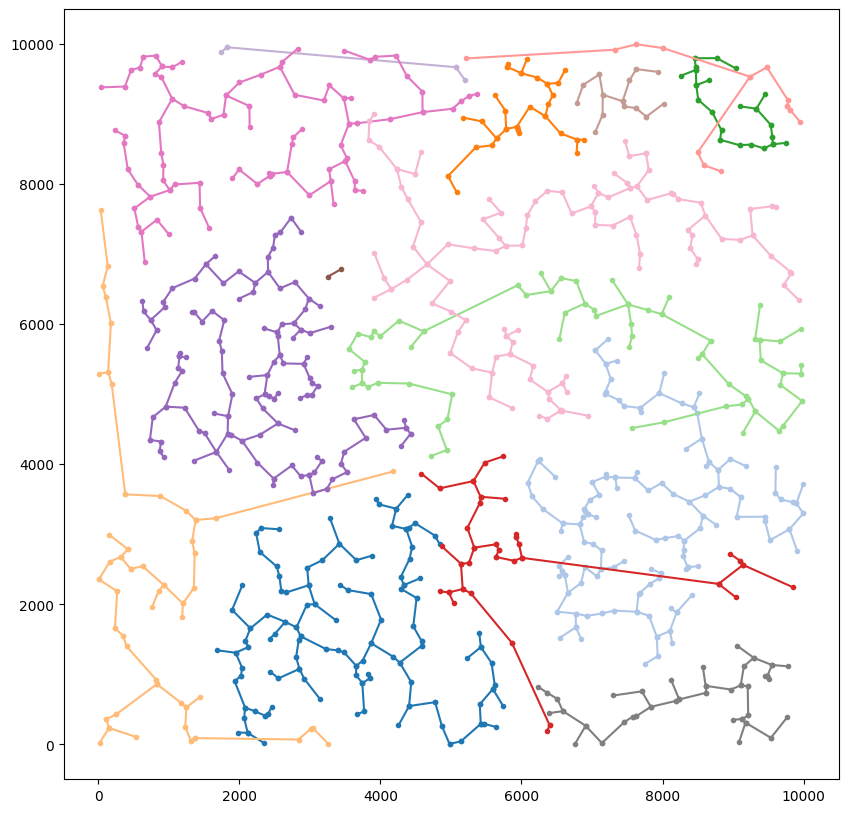

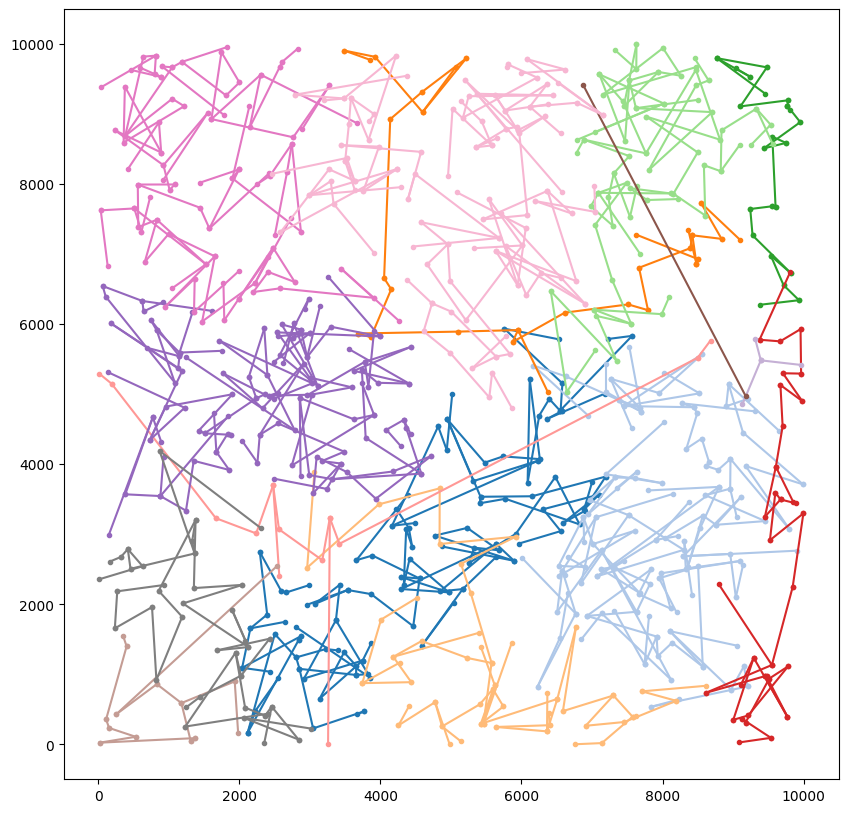

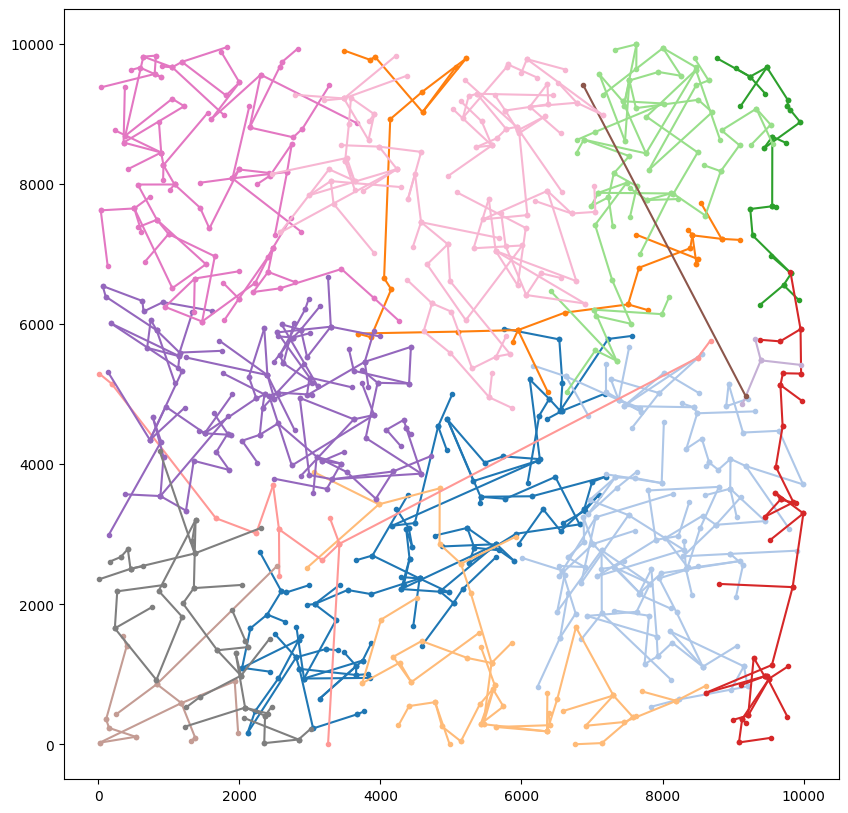

In [64]:
import matplotlib.pyplot as plt
import numpy as np


def get_color(i):
    colors = plt.get_cmap("tab20").colors
    return colors[i % len(colors)]


def draw_answer(ans_v, ans_edges):
    correct_coords = np.array(env.coordinates)
    plt.figure(figsize=(10, 10))

    for g, (vs, edges) in enumerate(zip(ans_v, ans_edges)):
        if len(vs) == 1:
            coord = correct_coords[vs][0]
            plt.scatter(coord[0], coord[1], color="black", marker="*", s=3)
        vs = np.array(vs)
        edges = np.array(edges)
        for e in edges:
            cs = correct_coords[e]
            plt.plot(
                cs[:, 0],
                cs[:, 1],
                color=get_color(g),
                marker="o",
                markersize=3,
            )
    plt.show()


draw_answer(anv_v_correct, ans_edges_correct)
draw_answer(anv_v_estimate, ans_edges_estimate)
draw_answer(ans_v_update, ans_edges_update)

In [ ]:
# point_inds = list(range(env.N))  # longs_points[:]
# corrects_np = np.array(corrects)[point_inds]
# estimates_np = np.array(estimates)[point_inds]
# rectangles = np.array([env.rectangles[i] for i in range(env.N)])[point_inds]

# # 四角形と、四角形内の正解点と予測点を描画
# plt.figure(figsize=(10, 10))
# ax = plt.gca()
# # for i, rect in enumerate(rectangles):
# #     l, r, t, b = rect
# #     ax.add_patch(matplotlib.patches.Rectangle((l, t), r - l, b - t, alpha=0.1))
# ax.scatter(corrects_np[:, 0], corrects_np[:, 1], color="green", label="correct", s=20, marker="*")
# ax.scatter(estimates_np[:, 0], estimates_np[:, 1], color="red", label="estimate", s=5, marker="o")
# for point_ind in range(len(corrects_np)):
#     ax.plot(
#         (corrects_np[point_ind, 0], estimates_np[point_ind, 0]),
#         (corrects_np[point_ind, 1], estimates_np[point_ind, 1]),
#         color="gray",
#         label="correct path",
#     )
# plt.show()